In [28]:
# ── imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path

# sklearn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, multilabel_confusion_matrix,
    roc_auc_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# tensorflow
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, optimizers, backend as K

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TARGETS = ["NORM", "MI", "STTC", "HYP", "CD"]

In [ ]:
gap_path = r"GAP_denim.csv"
sol_path = r"solutions.csv"
out_csv  = r"benazirbhutto.csv"
data=pd.read_csv('ECG_data.csv')
data1=data
data1=data1.drop("T_Amp_V5",axis=1)

In [30]:
def load_and_merge(gap_path: str, sol_path: str, out_path: str | None = None) -> pd.DataFrame:
    print("Loading GAP_denim.csv …")
    gap = pd.read_csv(gap_path)

    print("Loading solutions.csv …")
    sol = pd.read_csv(sol_path)[["ecg_id"] + TARGETS]

    print(f"  GAP rows : {len(gap):,}   |  Solutions rows : {len(sol):,}")

    merged = gap.merge(sol, on="ecg_id", how="inner")
    merged = merged[(merged != -1).all(axis=1)]
    print(f"  Merged   : {len(merged):,} rows")

    if out_path:
        merged.to_csv(out_path, index=False)
        print(f"  Saved merged file → {out_path}")

    return merged

In [31]:
df = load_and_merge(gap_path, sol_path, out_csv)

Loading GAP_denim.csv …
Loading solutions.csv …
  GAP rows : 17,441   |  Solutions rows : 17,441
  Merged   : 17,433 rows
  Saved merged file → benazirbhutto.csv


In [32]:
def prepare_features(df: pd.DataFrame):
    drop_cols = ["ecg_id"] + TARGETS
    X = df.drop(columns=drop_cols, errors="ignore")
    y = df[TARGETS].values.astype(np.float32)

    X = X.select_dtypes(include=[np.number])

    print(f"\nFeatures : {X.shape[1]}  |  Samples : {X.shape[0]}")
    print("Target distribution (% positive per label):")
    for col, vals in zip(TARGETS, y.T):
        print(f"  {col:6s}: {vals.mean()*100:.1f}%")

    medians = X.median()
    X = X.fillna(medians)

    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    X = X.clip(lower=Q1 - 3 * IQR, upper=Q3 + 3 * IQR, axis=1)

    feature_names = X.columns.tolist()
    return X.values.astype(np.float32), y, feature_names

In [33]:
def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    n_samples = len(y)
    label_weights = np.ones_like(y, dtype=np.float32)

    for j in range(y.shape[1]):
        pos = y[:, j].sum()
        neg = n_samples - pos
        w_pos = n_samples / (2 * pos) if pos > 0 else 1.0
        w_neg = n_samples / (2 * neg) if neg > 0 else 1.0
        label_weights[:, j] = np.where(y[:, j] == 1, w_pos, w_neg)

    sample_weights = label_weights.mean(axis=1)
    sample_weights /= sample_weights.mean()
    return sample_weights

In [34]:
def macro_f1(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)), axis=0)
    fp = K.sum(K.round(K.clip(y_pred - y_true, 0, 1)), axis=0)
    fn = K.sum(K.round(K.clip(y_true - y_pred, 0, 1)), axis=0)
    precision = tp / (tp + fp + K.epsilon())
    recall    = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

In [35]:
def build_model(n_features: int, n_labels: int = 5) -> tf.keras.Model:
    L2 = 1e-4
    inputs = layers.Input(shape=(n_features,), name="ecg_features")

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(L2))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.35)(x)

    skip = layers.Dense(256, use_bias=False)(inputs)
    x = layers.Add()([x, skip])

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(n_labels, activation="sigmoid", name="predictions")(x)

    return tf.keras.Model(inputs, outputs, name="ECG_ANN")

In [36]:
def tune_thresholds(y_true: np.ndarray, y_prob: np.ndarray) -> np.ndarray:
    thresholds = np.zeros(y_true.shape[1])
    for j in range(y_true.shape[1]):
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.20, 0.81, 0.02):
            preds = (y_prob[:, j] >= t).astype(int)
            f1 = f1_score(y_true[:, j], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[j] = best_t
        print(f"  {TARGETS[j]:6s} → threshold {best_t:.2f}  (val F1 {best_f1:.3f})")
    return thresholds

In [43]:
df = load_and_merge(gap_path, sol_path, out_csv)
X, y, feature_names = prepare_features(df)

norm_col = y[:, TARGETS.index("NORM")]

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=norm_col
)

norm_col_tv = y_tv[:, TARGETS.index("NORM")]
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, random_state=SEED, stratify=norm_col_tv
)

print(f"\nSplit — train:{len(X_train)}  val:{len(X_val)}  test:{len(X_test)}")

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

sw_train = compute_sample_weights(y_train)

model = build_model(X_train.shape[1], len(TARGETS))

lr_schedule = optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-3,
    first_decay_steps=10,
    t_mul=2.0,
    m_mul=0.9,
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc", multi_label=True), macro_f1],
)

cb_list = [
    callbacks.EarlyStopping(monitor="val_macro_f1", mode="max", patience=12, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max", factor=0.5, patience=5),
    callbacks.ModelCheckpoint("best_ecg_model.keras", monitor="val_macro_f1", mode="max", save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    sample_weight=sw_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
)

Loading GAP_denim.csv …
Loading solutions.csv …
  GAP rows : 17,441   |  Solutions rows : 17,441
  Merged   : 17,433 rows
  Saved merged file → benazirbhutto.csv

Features : 48  |  Samples : 17433
Target distribution (% positive per label):
  NORM  : 43.6%
  MI    : 25.2%
  STTC  : 24.0%
  HYP   : 12.2%
  CD    : 22.4%

Split — train:12203  val:2615  test:2615
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - auc: 0.7791 - loss: 0.5771 - macro_f1: 0.5359 - val_auc: 0.8406 - val_loss: 0.5451 - val_macro_f1: 0.5831
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.8545 - loss: 0.4829 - macro_f1: 0.6137 - val_auc: 0.8674 - val_loss: 0.4594 - val_macro_f1: 0.6364
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.8696 - loss: 0.4612 - macro_f1: 0.6368 - val_auc: 0.8752 - val_loss: 0.4206 - val_macro_f1: 0.6464
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.8724 - loss: 0.4546 - macro_f1: 0.6451 - val_auc: 0.8747 - val_loss: 0.4163 - val_macro_f1: 0.6553


In [12]:
data=pd.read_csv('ECG_data.csv')

In [59]:

X, y, feature_names = prepare_features(data1)

norm_col = y[:, TARGETS.index("NORM")]

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=norm_col
)

norm_col_tv = y_tv[:, TARGETS.index("NORM")]
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, random_state=SEED, stratify=norm_col_tv
)

print(f"\nSplit — train:{len(X_train)}  val:{len(X_val)}  test:{len(X_test)}")

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

sw_train = compute_sample_weights(y_train)

model = build_model(X_train.shape[1], len(TARGETS))

lr_schedule = optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-3,
    first_decay_steps=10,
    t_mul=2.0,
    m_mul=0.9,
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc", multi_label=True), macro_f1],
)



history = model.fit(
    X_train, y_train,
    sample_weight=sw_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
)


Features : 21  |  Samples : 17441
Target distribution (% positive per label):
  NORM  : 43.6%
  MI    : 25.2%
  STTC  : 24.0%
  HYP   : 12.2%
  CD    : 22.4%

Split — train:12208  val:2616  test:2617
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.7476 - loss: 0.6155 - macro_f1: 0.4862 - val_auc: 0.8377 - val_loss: 0.5174 - val_macro_f1: 0.5937
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8218 - loss: 0.5126 - macro_f1: 0.5634 - val_auc: 0.8456 - val_loss: 0.4596 - val_macro_f1: 0.5942
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.8362 - loss: 0.4927 - macro_f1: 0.5859 - val_auc: 0.8496 - val_loss: 0.4472 - val_macro_f1: 0.5696
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8410 - loss: 0.4863 - macro_f1: 0.5906 - val_auc: 0.8532 - val_loss: 0.4353 - val_macro_f1: 0.5931
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8469 - loss: 0.4765 - macro_f1: 0.5937 - val_auc: 0.8587 - val_loss: 0.4263 - val_macro_f1: 0.5950
Epo

In [60]:
val_probs = model.predict(X_val)
thresholds = tune_thresholds(y_val, val_probs)

test_probs = model.predict(X_test)
test_preds = (test_probs >= thresholds).astype(int)

print(classification_report(y_test, test_preds, target_names=TARGETS))

print("Macro F1:", f1_score(y_test, test_preds, average="macro"))
print("Micro F1:", f1_score(y_test, test_preds, average="micro"))

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  NORM   → threshold 0.38  (val F1 0.804)
  MI     → threshold 0.38  (val F1 0.661)
  STTC   → threshold 0.34  (val F1 0.606)
  HYP    → threshold 0.42  (val F1 0.584)
  CD     → threshold 0.46  (val F1 0.674)
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
              precision    recall  f1-score   support

        NORM       0.75      0.85      0.80      1141
          MI       0.63      0.70      0.67       645
        STTC       0.57      0.64      0.60       637
         HYP       0.59      0.58      0.59       324
          CD       0.68      0.63      0.66       592

   micro avg       0.67      0.72      0.69      3339
   macro avg       0.64      0.68      0.66      3339
weighted avg       0.66      0.72      0.69      3339
 samples avg       0.68      0.72      0.68      3339

Macro F1: 0.6610705682568321
Micro F1: 0.6902017291066282


c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

In [45]:
data1.shape

(17441, 27)

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, multilabel_confusion_matrix
def plot_classification_report(y_true, y_pred, title="Classification Report"):
    report = classification_report(y_true, y_pred, target_names=TARGETS, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    # keep only label rows
    df_report = df_report.loc[TARGETS]

    plt.figure(figsize=(8, 5))
    sns.heatmap(df_report.iloc[:, :-1], annot=True, fmt=".2f", cmap="Blues")

    plt.title(title)
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.tight_layout()
    plt.show()

In [57]:
def plot_confusion_matrices(y_true, y_pred):
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    n_classes = len(TARGETS)
    cols = 3
    rows = int(np.ceil(n_classes / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i, (cm, label) in enumerate(zip(mcm, TARGETS)):
        plt.subplot(rows, cols, i + 1)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"]
        )

        plt.title(label)
        plt.xlabel("Prediction")
        plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tatik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

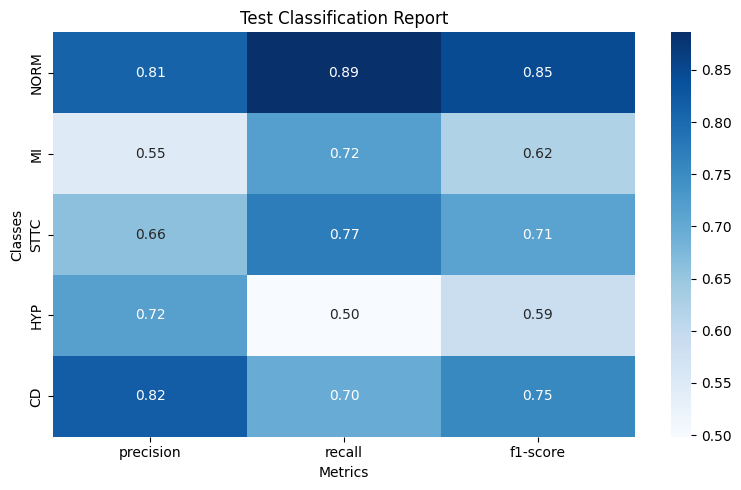

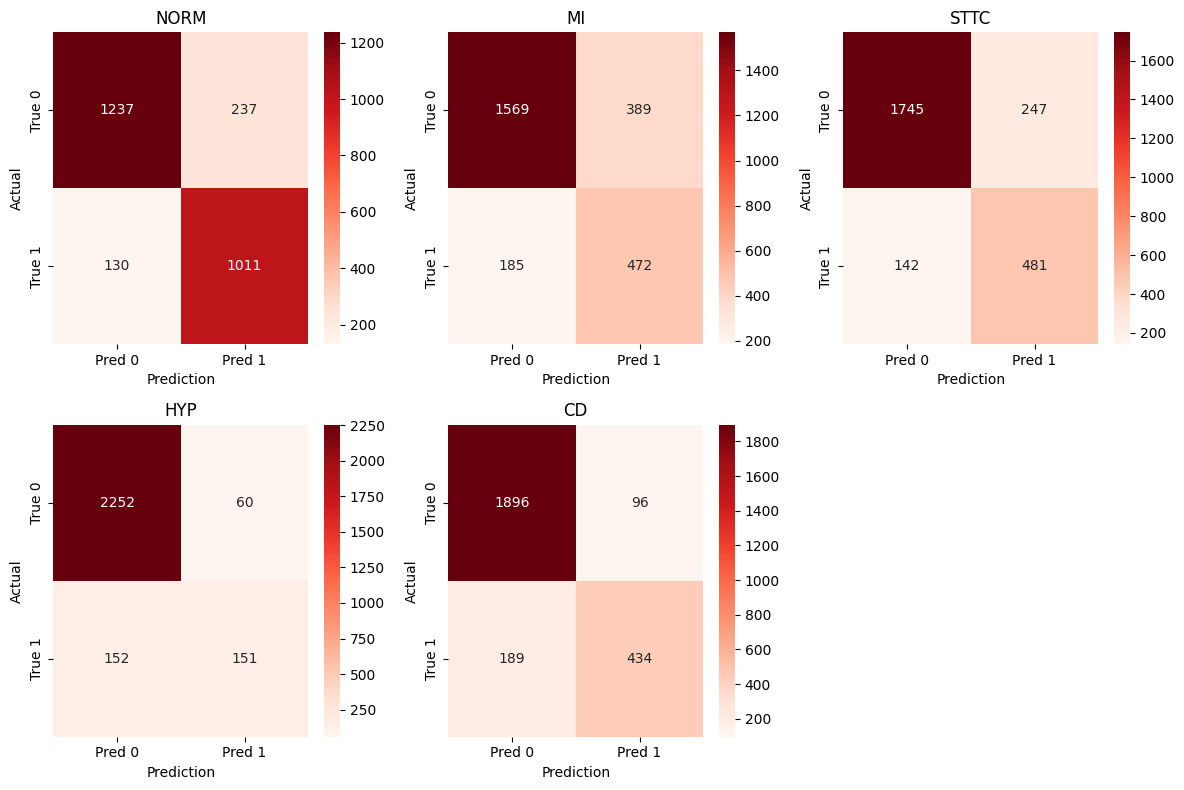

In [58]:

plot_classification_report(y_test, test_preds, title="Test Classification Report")
plot_confusion_matrices(y_test, test_preds)